In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import time
from collections import defaultdict 

In [2]:


# --- Step 1: Form the Transactional Dataset ---

# Load the datasets from their respective CSV files
orders_df = pd.read_csv('orders.csv')
order_products_train_df = pd.read_csv('order_products__train.csv')

# 1.1: Identify all orders where eval_set is 'train'
print("Filtering for 'train' orders...")
train_orders_df = orders_df[orders_df['eval_set'] == 'train']

# 1.2: Merge with order_products_train to get product details for each train order
# We only need the 'order_id' from train_orders_df for the merge
print("Merging train orders with product data...")
transaction_df = pd.merge(
    train_orders_df[['order_id']],
    order_products_train_df[['order_id', 'product_id']],
    on='order_id'
)

# 1.3: Create a list of transactions (order_id with a set of product_ids)
# We group by 'order_id' and aggregate the 'product_id's into a set
print("Grouping products by order to form transactions...")
transactional_dataset = transaction_df.groupby('order_id')['product_id'].apply(set).reset_index()
transactional_dataset.columns = ['order_id', 'product_ids']

print("\nTransactional dataset created successfully.")
print("Sample of the transactional dataset:")
print(transactional_dataset.head())


# --- Step 2: Split the Data ---

# 2.1: Randomly divide the dataset into training (80%) and test (20%) sets
# We use random_state for reproducibility, so the split is the same every time
print("\nSplitting data into training (80%) and test (20%) sets...")
train_set, test_set = train_test_split(
    transactional_dataset,
    test_size=0.2,
    random_state=42  # Using a fixed seed for reproducibility
)

print("Data splitting complete.")

# --- Verification ---

# Display the size and a sample of the final datasets
print(f"\nTraining set contains {len(train_set)} transactions.")
print("Sample of the training set:")
print(train_set.head())

print(f"\nTest set contains {len(test_set)} transactions.")
print("Sample of the test set:")
print(test_set.head())

#Save the resulting datasets to new CSV files for later use
train_set.to_csv('train_transactions.csv', index=False)
test_set.to_csv('test_transactions.csv', index=False)



Filtering for 'train' orders...
Merging train orders with product data...
Grouping products by order to form transactions...

Transactional dataset created successfully.
Sample of the transactional dataset:
   order_id                                        product_ids
0         1  {11109, 10246, 47209, 43633, 49683, 22035, 493...
1        36  {34497, 46979, 48679, 19660, 43086, 49235, 396...
2        38  {42625, 23622, 11913, 28842, 4461, 39693, 1815...
3        96  {40706, 24489, 25610, 39275, 30391, 20574, 27966}
4        98  {46720, 24964, 4357, 43654, 18441, 36364, 3406...

Splitting data into training (80%) and test (20%) sets...
Data splitting complete.

Training set contains 104967 transactions.
Sample of the training set:
       order_id                                        product_ids
29221    752925                {12576, 21344, 14467, 22281, 13292}
89111   2314811  {25952, 11009, 5923, 196, 5385, 45290, 25706, ...
66632   1723799  {26209, 17794, 44359, 1999, 34358, 34551,

Loading and preparing data...
Loaded 104967 transactions for training.

Starting threshold experimentation with from-scratch FP-Growth...

Running for minsup_ratio = 0.0005 (count = 52)...
  - For minconf=0.01, min_lift=1.0: found 16985 rules.
  - For minconf=0.01, min_lift=1.5: found 15440 rules.
  - For minconf=0.01, min_lift=2.0: found 12273 rules.
  - For minconf=0.025, min_lift=1.0: found 11561 rules.
  - For minconf=0.025, min_lift=1.5: found 10453 rules.
  - For minconf=0.025, min_lift=2.0: found 8047 rules.
  - For minconf=0.05, min_lift=1.0: found 6844 rules.
  - For minconf=0.05, min_lift=1.5: found 6143 rules.
  - For minconf=0.05, min_lift=2.0: found 4655 rules.
  - For minconf=0.075, min_lift=1.0: found 4666 rules.
  - For minconf=0.075, min_lift=1.5: found 4113 rules.
  - For minconf=0.075, min_lift=2.0: found 3017 rules.
  - For minconf=0.1, min_lift=1.0: found 3535 rules.
  - For minconf=0.1, min_lift=1.5: found 3085 rules.
  - For minconf=0.1, min_lift=2.0: found 2181 

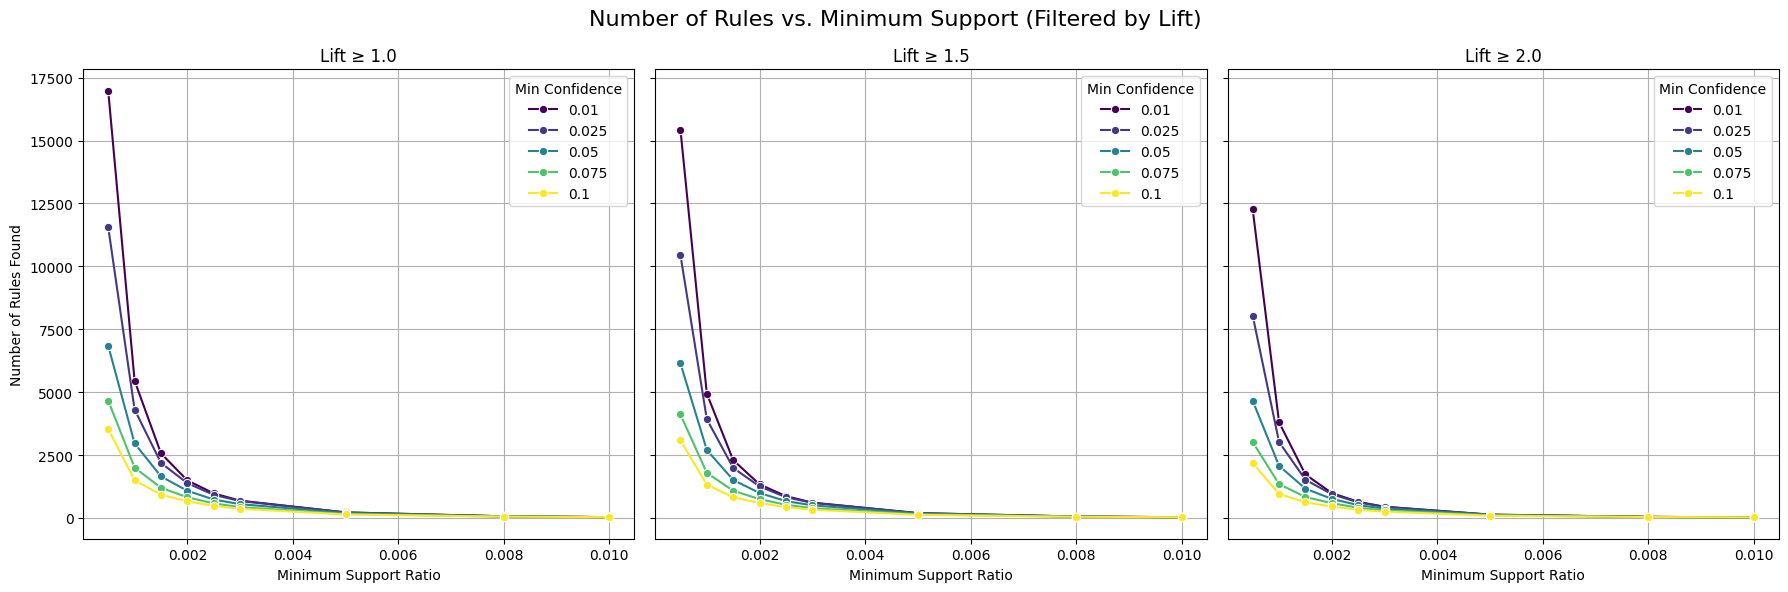

In [3]:

# Part 1: FP-Growth and Association Rule Mining Implementation from Scratch

class FPNode:
    """A node in the FP-Tree."""
    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None 

    def increment(self, count):
        """Increment the count of the node."""
        self.count += count

def build_fp_tree(transactions, min_support_count):
    """Builds the FP-Tree and the header table."""
    # 1. First pass: counting the frequency of each item
    item_counts = {}
    for transaction in transactions:
        for item in transaction:
            item_counts[item] = item_counts.get(item, 0) + 1

    # Filtering items below min_support_count
    frequent_items = {item: count for item, count in item_counts.items() if count >= min_support_count}
    
    if not frequent_items:
        return None, None

    # Creating the header table, which maps each frequent item to its count and a node link
    header_table = {item: [count, None] for item, count in frequent_items.items()}

    # 2. Second pass: building the FP-Tree
    root = FPNode(None, 1, None)
    for transaction in transactions:
        # Filter and sort the transaction based on global item frequency
        sorted_items = [item for item in transaction if item in frequent_items]
        sorted_items.sort(key=lambda item: header_table[item][0], reverse=True)
        
        # Insert the sorted transaction into the tree
        current_node = root
        for item in sorted_items:
            # Check if item is already a child of the current node
            child = current_node.children.get(item)
            if child:
                child.increment(1)
            else:
                # Create a new node
                child = FPNode(item, 1, current_node)
                current_node.children[item] = child
                
                # Update the header table to link to this new node
                if header_table[item][1] is None:
                    header_table[item][1] = child
                else:
                    # Traverse the node links to find the last one and append
                    linked_node = header_table[item][1]
                    while linked_node.node_link is not None:
                        linked_node = linked_node.node_link
                    linked_node.node_link = child
            
            current_node = child
            
    return root, header_table

def find_prefix_paths(node):
    """Finds all prefix paths for a given node in the FP-Tree."""
    paths = []
    while node is not None:
        path = []
        ascendant = node
        while ascendant.parent is not None and ascendant.parent.item is not None:
            path.append(ascendant.parent.item)
            ascendant = ascendant.parent
        if path:
            paths.append((path, node.count))
        node = node.node_link
    return paths

def mine_fp_tree(header_table, min_support_count, prefix, frequent_itemsets, prefix_support=None):
    sorted_items = sorted(header_table.items(), key=lambda p: p[1][0])
    
    for item, data in sorted_items:
        new_prefix = prefix.copy()
        new_prefix.add(item)
        
        support_count = data[0]
        
        frequent_itemsets.append((frozenset(new_prefix), support_count))
        
        # Find prefix paths
        prefix_paths = find_prefix_paths(header_table[item][1])
        
        # Build conditional transactions
        conditional_transactions = []
        for path, count in prefix_paths:
            for _ in range(count):
                conditional_transactions.append(path)
        
        # Build conditional FP-Tree
        cond_tree, cond_header = build_fp_tree(conditional_transactions, min_support_count)
        
        # Recursively mine with support constraint
        if cond_header is not None:
            mine_fp_tree(cond_header, min_support_count, new_prefix, frequent_itemsets, support_count)


def fp_growth_from_scratch(transactions, min_support_count):
    """The main function to run the FP-Growth algorithm from scratch."""
    root, header_table = build_fp_tree(transactions, min_support_count)
    if header_table is None:
        return []
    
    frequent_itemsets = []
    mine_fp_tree(header_table, min_support_count, set(), frequent_itemsets)
    return frequent_itemsets


# Association Rule Generation with Lift Calculation

def generate_association_rules_with_lift(frequent_itemsets, min_confidence, min_lift=1.0, total_transactions=None):
    """Generates association rules from frequent itemsets with lift calculation and filtering."""
    if total_transactions is None:
        raise ValueError("total_transactions must be provided for lift calculation")
    
    # Create dictionaries for quick support lookups
    itemset_support_dict = {itemset: support for itemset, support in frequent_itemsets}
    
    rules = []
    for itemset, support in frequent_itemsets:
        if len(itemset) > 1:
            # As per assignment, antecedent must be a single product
            for A in itemset:
                antecedent = frozenset([A])
                consequent = itemset - antecedent
                
                # Get supports for lift calculation
                antecedent_support = itemset_support_dict.get(antecedent)
                consequent_support = itemset_support_dict.get(consequent)
                
                if antecedent_support and consequent_support:
                    confidence = support / antecedent_support
                    
                    # Calculate lift: P(A∪B) / (P(A) * P(B))
                    expected_support = (antecedent_support * consequent_support) / total_transactions
                    lift = support / expected_support if expected_support > 0 else 1.0
                    
                    if confidence >= min_confidence and lift >= min_lift:
                        rules.append((antecedent, consequent, confidence, support, lift))
    
    return rules

def filter_rules_by_lift(rules, min_lift=1.0):
    """Filters existing rules by lift threshold."""
    return [rule for rule in rules if rule[4] >= min_lift]  # rule[4] is lift


# Part 2: Main Workflow for the Assignment

# --- Load and Prepare Data ---
print("Loading and preparing data...")
train_df = pd.read_csv('train_transactions.csv')
transactions = train_df['product_ids'].apply(eval).tolist()
total_transactions = len(transactions)
print(f"Loaded {total_transactions} transactions for training.")

# --- Experiment with Thresholds ---
minsup_ratios = [0.0005,0.001, 0.0015 ,0.002, 0.0025, 0.003 , 0.005, 0.008, 0.01]
minconf_values = [0.01,0.025,0.05, 0.075, 0.1]
min_lift_values = [1.0, 1.5, 2.0] 
experiment_results = []

print("\nStarting threshold experimentation with from-scratch FP-Growth...")

for minsup_ratio in minsup_ratios:
    # Convert support ratio to an absolute count
    minsup_count = int(minsup_ratio * total_transactions)
    print(f"\nRunning for minsup_ratio = {minsup_ratio} (count = {minsup_count})...")
    
    start_time = time.time()
    
    # 1. Mine frequent itemsets with the from-scratch implementation
    frequent_itemsets = fp_growth_from_scratch(transactions, minsup_count)
    
    if not frequent_itemsets:
        print("  No frequent itemsets found. Skipping confidence checks.")
        for minconf in minconf_values:
            for min_lift in min_lift_values:
                experiment_results.append({
                    'minsup': minsup_ratio,
                    'minconf': minconf,
                    'min_lift': min_lift,
                    'num_rules': 0
                })
        continue

    # 2. Generate association rules for each confidence and lift level
    for minconf in minconf_values:
        for min_lift in min_lift_values:
            rules = generate_association_rules_with_lift(
                frequent_itemsets, minconf, min_lift, total_transactions
            )
            num_rules = len(rules)
            experiment_results.append({
                'minsup': minsup_ratio,
                'minconf': minconf,
                'min_lift': min_lift,
                'num_rules': num_rules
            })
            print(f"  - For minconf={minconf}, min_lift={min_lift}: found {num_rules} rules.")
    
    end_time = time.time()
    print(f"  Completed in {end_time - start_time:.2f} seconds.")

# --- Plot the Results with Lift ---
results_df = pd.DataFrame(experiment_results)
print("\nThreshold experimentation complete. Plotting results...")

# Create subplots for different lift values
fig, axes = plt.subplots(1, len(min_lift_values), figsize=(18, 6), sharey=True)
if len(min_lift_values) == 1:
    axes = [axes]

for idx, min_lift in enumerate(min_lift_values):
    lift_subset = results_df[results_df['min_lift'] == min_lift]
    sns.lineplot(data=lift_subset, x='minsup', y='num_rules', 
                 hue='minconf', marker='o', palette='viridis', ax=axes[idx])
    axes[idx].set_title(f'Lift ≥ {min_lift}')
    axes[idx].set_xlabel('Minimum Support Ratio')
    if idx == 0:
        axes[idx].set_ylabel('Number of Rules Found')
    axes[idx].legend(title='Min Confidence')
    axes[idx].grid(True)

plt.suptitle('Number of Rules vs. Minimum Support (Filtered by Lift)', fontsize=16)
plt.tight_layout()
plt.show()




Loading test data and product names...

--- Part 2: Preparing test set inputs and ground truths ---
Created 24838 input/ground truth pairs for evaluation.

--- Part 2.5: Threshold Evaluation using F1-Score ---

Evaluating for minsup_ratio = 0.001...

Evaluating for minsup_ratio = 0.0015...

Evaluating for minsup_ratio = 0.002...


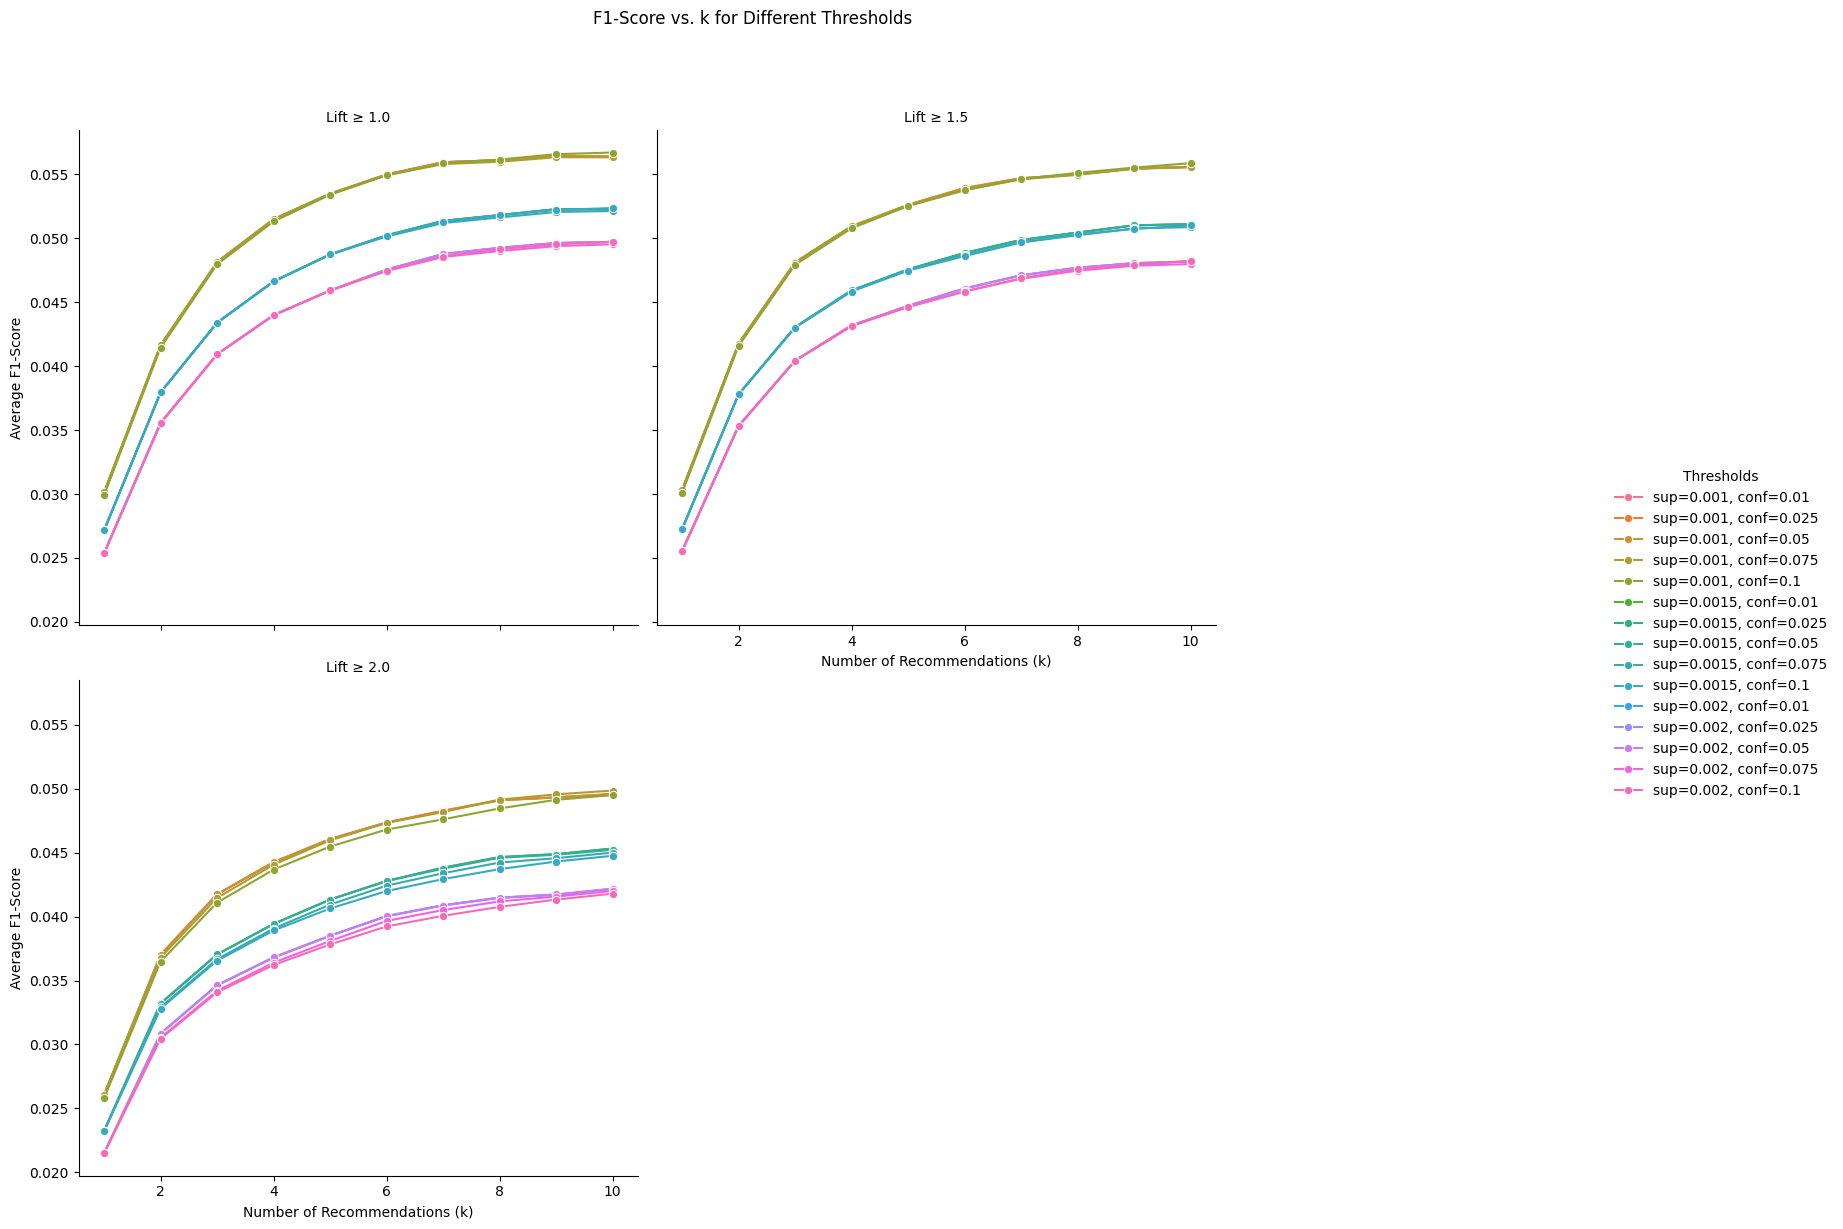

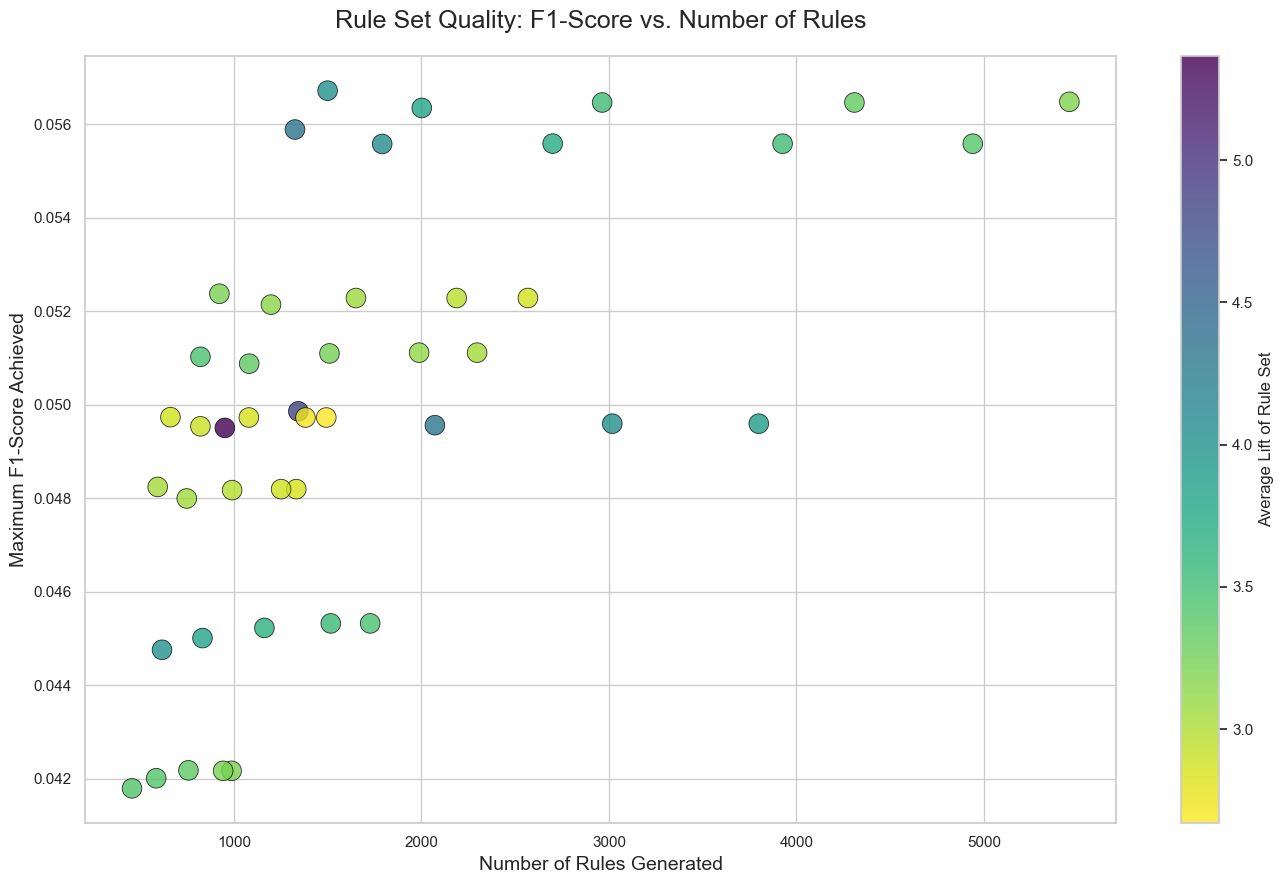

In [4]:

# --- Load necessary data ---
print("Loading test data and product names...")
test_df = pd.read_csv('test_transactions.csv')
test_transactions = test_df['product_ids'].apply(eval).tolist()
products_df = pd.read_csv('products.csv')
product_id_to_name = pd.Series(products_df.product_name.values, index=products_df.product_id.astype(str)).to_dict()

print("\n--- Part 2: Preparing test set inputs and ground truths ---")
test_inputs = []
test_ground_truths = []

for transaction in test_transactions:
    items = list(transaction)
    if len(items) >= 2:
        # Split the transaction list in half
        split_point = len(items) // 2
        input_items = set(items[:split_point])
        ground_truth_items = set(items[split_point:])
        
        # Ensure input and ground truth are not empty after splitting
        if input_items and ground_truth_items:
            test_inputs.append(input_items)
            test_ground_truths.append(ground_truth_items)

print(f"Created {len(test_inputs)} input/ground truth pairs for evaluation.")

# Part 2.5: Automated Threshold Evaluation using F1-Score

print("\n--- Part 2.5: Threshold Evaluation using F1-Score ---")

# Define the grid of parameters to search
minsup_ratios_to_test = [0.001, 0.0015, 0.002]
minconf_values_to_test = [0.01,0.025,0.05, 0.075,0.1]
min_lift_to_test = [1.0, 1.5, 2.0]
recommendation_counts = range(1, 11)

# This will store the performance of every combination
evaluation_results = []

def calculate_precision_recall(recommended_set, ground_truth_set):
    """Calculates precision and recall for a single prediction."""
    if not ground_truth_set: return 0.0, 0.0
    
    true_positives = len(recommended_set.intersection(ground_truth_set))
    
    precision = true_positives / len(recommended_set) if recommended_set else 0.0
    recall = true_positives / len(ground_truth_set)
    
    return precision, recall

def get_recommendations_for_eval(input_set, k, rules_dict):
    """Helper function for this loop to generate recommendations based on a given rule dict."""
    candidate_items = {}
    for item in input_set:
        if item in rules_dict:
            for rule_data in rules_dict[item]:
                
                if len(rule_data) == 2:
                    consequent_set, confidence = rule_data
                else:  
                    consequent_set, confidence, lift = rule_data
                
                for cons_item in consequent_set:
                    if cons_item not in input_set:
                        candidate_items[cons_item] = max(candidate_items.get(cons_item, 0.0), confidence)
    
    sorted_candidates = sorted(candidate_items.items(), key=lambda x: x[1], reverse=True)
    return {item for item, score in sorted_candidates[:k]}

# --- Main Evaluation Loop with Lift ---
for minsup_ratio in minsup_ratios_to_test:
    minsup_count = int(minsup_ratio * total_transactions)
    print(f"\nEvaluating for minsup_ratio = {minsup_ratio}...")
    
    # Mine frequent itemsets once for this minsup
    frequent_itemsets = fp_growth_from_scratch(transactions, minsup_count)
    
    for minconf in minconf_values_to_test:
        for min_lift in min_lift_to_test:
            # Generate rules WITH LIFT FILTERING
            rules = generate_association_rules_with_lift(
                frequent_itemsets, minconf, min_lift, total_transactions
            )
            
            # Build the local rule dictionary
            local_rules_dict = {}
            for ant, con, conf, sup, lift in rules:  
                if len(ant) == 1:
                    ant_item = list(ant)[0]
                    if ant_item not in local_rules_dict: 
                        local_rules_dict[ant_item] = []
                    local_rules_dict[ant_item].append((con, conf, lift))  
            
            # Sort by confidence (you could also sort by lift * confidence)
            for item in local_rules_dict:
                local_rules_dict[item].sort(key=lambda x: x[1], reverse=True)  # Sort by confidence
            
            # Evaluate this rule set across all k
            for k in recommendation_counts:
                precisions, recalls = [], []
                for i in range(len(test_inputs)):
                    recs = get_recommendations_for_eval(test_inputs[i], k, local_rules_dict)
                    prec, rec = calculate_precision_recall(recs, test_ground_truths[i])
                    precisions.append(prec)
                    recalls.append(rec)
                
                avg_prec = np.mean(precisions)
                avg_rec = np.mean(recalls)
                f1 = 2 * (avg_prec * avg_rec) / (avg_prec + avg_rec) if (avg_prec + avg_rec) > 0 else 0
                
                evaluation_results.append({
                    'minsup': minsup_ratio,
                    'minconf': minconf,
                    'min_lift': min_lift,
                    'k': k,
                    'f1_score': f1,
                    'num_rules': len(rules),
                    'avg_lift': np.mean([rule[4] for rule in rules]) if rules else 0
                })


# Plot
f1_df = pd.DataFrame(evaluation_results)

f1_df['Thresholds'] = f1_df.apply(
    lambda row: f"sup={row['minsup']}, conf={row['minconf']}", axis=1
)

g = sns.FacetGrid(f1_df, col="min_lift", hue="Thresholds", col_wrap=2, height=6, aspect=1.1)
g.map(sns.lineplot, "k", "f1_score", marker="o")
g.set_axis_labels("Number of Recommendations (k)", "Average F1-Score")
g.set_titles("Lift ≥ {col_name}")
g.add_legend(title='Thresholds', bbox_to_anchor=(1.05, 0.5), loc='center left')
g.fig.suptitle('F1-Score vs. k for Different Thresholds', y=1.02)
plt.subplots_adjust(top=0.92, right=0.8) 
plt.show()

# Scatter Plot ---

sns.set_theme(style="whitegrid", palette="viridis")
plt.figure(figsize=(14, 9))
quality_metrics = f1_df.groupby(['minsup', 'minconf', 'min_lift']).agg({
    'f1_score': 'max',
    'num_rules': 'first',
    'avg_lift': 'first'
}).reset_index()

scatter = plt.scatter(
    quality_metrics['num_rules'], 
    quality_metrics['f1_score'], 
    c=quality_metrics['avg_lift'], 
    cmap='viridis_r', 
    s=200,            
    alpha=0.8,        
    edgecolors='k',
    linewidth=0.6
)

cbar = plt.colorbar(scatter)
cbar.set_label('Average Lift of Rule Set', fontsize=12)

plt.title('Rule Set Quality: F1-Score vs. Number of Rules', fontsize=18, pad=20)
plt.xlabel('Number of Rules Generated', fontsize=14)
plt.ylabel('Maximum F1-Score Achieved', fontsize=14)


plt.tight_layout()
plt.show()






Loading product data to map IDs to names...

Generating final rules with minsup=0.0015, minconf=0.075, min_lift=1.5...
Found 1082 final rules after lift filtering.

Support Distribution Check:
Min support: 157
Max support: 14949
Mean support: 405.2229979466119
Found 1082 final rules.

Lift Statistics:
  Min Lift: 1.511
  Max Lift: 71.822
  Avg Lift: 3.343
  Rules with lift > 3.0: 369
  Rules with lift > 5.0: 81


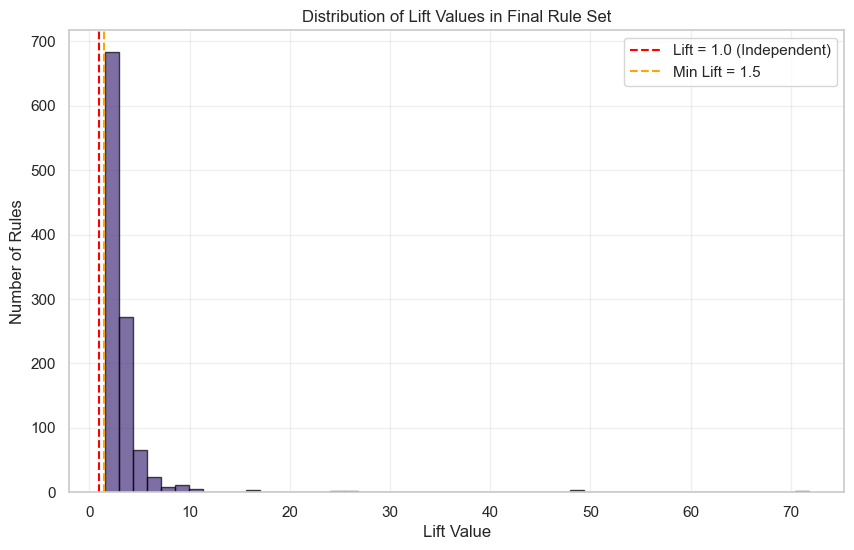


Sample of Final Readable Rules (Antecedent -> Consequent | Confidence, Support):
  {'Non Fat Raspberry Yogurt'} -> {'Icelandic Style Skyr Blueberry Non-fat Yogurt'}
    | Confidence: 0.380, Support: 0.0017, Lift: 71.822

  {'Icelandic Style Skyr Blueberry Non-fat Yogurt'} -> {'Non Fat Raspberry Yogurt'}
    | Confidence: 0.315, Support: 0.0017, Lift: 71.822

  {'XL Emerald White Seedless Grapes'} -> {'Banana'}
    | Confidence: 0.319, Support: 0.0015, Lift: 2.242

  {'Asparation/Broccolini/Baby Broccoli'} -> {'Banana'}
    | Confidence: 0.343, Support: 0.0016, Lift: 2.410

  {'Total 2% with Strawberry Lowfat Greek Strained Yogurt'} -> {'Total 2% Lowfat Greek Strained Yogurt with Peach'}
    | Confidence: 0.232, Support: 0.0017, Lift: 48.076

  {'Total 2% Lowfat Greek Strained Yogurt with Peach'} -> {'Total 2% with Strawberry Lowfat Greek Strained Yogurt'}
    | Confidence: 0.358, Support: 0.0017, Lift: 48.076

  {'Globe Eggplant'} -> {'Organic Zucchini'}
    | Confidence: 0.313, Suppo

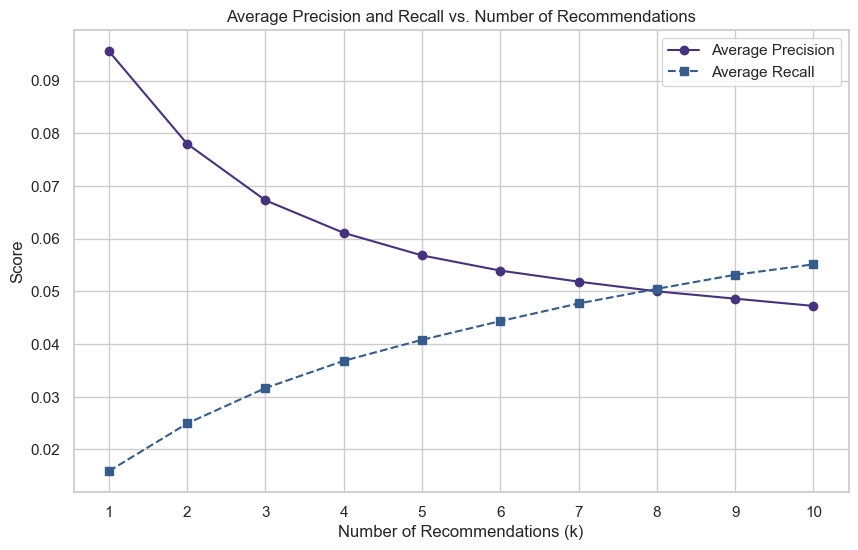

In [5]:
# Part 3: Generate and Display Final Rules with Product Names

# --- Load Product Names ---
print("\nLoading product data to map IDs to names...")
products_df = pd.read_csv('products.csv')
product_id_to_name = pd.Series(products_df.product_name.values, index=products_df.product_id.astype(str)).to_dict()


# --- Generate Final Rules ---
FINAL_MINSUP_RATIO = 0.0015
FINAL_MINCONF = 0.075
FINAL_MIN_LIFT = 1.5
final_minsup_count = int(FINAL_MINSUP_RATIO * total_transactions)

print(f"\nGenerating final rules with minsup={FINAL_MINSUP_RATIO}, minconf={FINAL_MINCONF}, min_lift={FINAL_MIN_LIFT}...")
final_frequent_itemsets = fp_growth_from_scratch(transactions, final_minsup_count)
final_rules = generate_association_rules_with_lift(
    final_frequent_itemsets, FINAL_MINCONF, FINAL_MIN_LIFT, total_transactions
)

print(f"Found {len(final_rules)} final rules after lift filtering.")
print("\nSupport Distribution Check:")
supports = [sup for itemset, sup in final_frequent_itemsets]
print(f"Min support: {min(supports)}")
print(f"Max support: {max(supports)}")
print(f"Mean support: {np.mean(supports)}")

if max(supports) > total_transactions:
    print("⚠️ BUG DETECTED: Support values exceed total transactions!")
print(f"Found {len(final_rules)} final rules.")


# --- Display Rules with Product Names ---
# --- Analyze Lift Distribution ---
if final_rules:
    lifts = [rule[4] for rule in final_rules]  # rule[4] is lift
    print(f"\nLift Statistics:")
    print(f"  Min Lift: {min(lifts):.3f}")
    print(f"  Max Lift: {max(lifts):.3f}")
    print(f"  Avg Lift: {np.mean(lifts):.3f}")
    print(f"  Rules with lift > 3.0: {len([l for l in lifts if l > 3.0])}")
    print(f"  Rules with lift > 5.0: {len([l for l in lifts if l > 5.0])}")
    
    # Plot lift distribution
    plt.figure(figsize=(10, 6))
    plt.hist(lifts, bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(x=1.0, color='red', linestyle='--', label='Lift = 1.0 (Independent)')
    plt.axvline(x=FINAL_MIN_LIFT, color='orange', linestyle='--', label=f'Min Lift = {FINAL_MIN_LIFT}')
    plt.xlabel('Lift Value')
    plt.ylabel('Number of Rules')
    plt.title('Distribution of Lift Values in Final Rule Set')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


print("\nSample of Final Readable Rules (Antecedent -> Consequent | Confidence, Support):")

def get_names_from_ids(id_set, mapping):
    return {mapping.get(str(pid), f"ID:{pid}") for pid in id_set}

for antecedent_ids, consequent_ids, confidence, support, lift in final_rules[:10]:
    antecedent_name = list(get_names_from_ids(antecedent_ids, product_id_to_name))[0]
    consequent_names = get_names_from_ids(consequent_ids, product_id_to_name)
    support_ratio = support / total_transactions
    
    print(f"  {{'{antecedent_name}'}} -> {consequent_names}")
    print(f"    | Confidence: {confidence:.3f}, Support: {support_ratio:.4f}, Lift: {lift:.3f}")
    print()



# Verification: Check for Rules with Multi-Product Consequents

print("\n\n--- Verification: Checking for rules with multi-product consequents ---")

# Filter the final_rules list to find rules where the consequent has more than one item
multi_item_consequent_rules = [
    rule for rule in final_rules if len(rule[1]) > 1
]

if not multi_item_consequent_rules:
    print("No rules with more than one product in the consequent were found at the current thresholds.")
    print("The rule generation logic is correct, but no such rules met the minimum support and confidence criteria.")
else:
    print(f"Found {len(multi_item_consequent_rules)} rules with more than one product in the consequent:")
    print("--------------------------------------------------")
    
    # Iterate through and print the multi-item consequent rules
    for rule in multi_item_consequent_rules:
        antecedent_ids, consequent_ids, confidence, support, lift = rule  
        # Convert IDs to names for printing
        antecedent_name = list(get_names_from_ids(antecedent_ids, product_id_to_name))[0]
        consequent_names = get_names_from_ids(consequent_ids, product_id_to_name)
        
        # Calculate support ratio
        support_ratio = support / total_transactions
        
        print(f"  {{'{antecedent_name}'}} -> {consequent_names} "
              f"| (conf: {confidence:.3f}, sup: {support_ratio:.4f}, lift: {lift:.3f})")
    print("--------------------------------------------------")


# Part 3: Calculate and Plot Average Precision and Recall
print("\n--- Part 3: Calculating and plotting average metrics ---")

rules_dict = {}
for rule in final_rules:
    antecedent, consequent, confidence, support, lift = rule  
    # This ensures we only use rules of the form {A} -> Y
    if len(antecedent) == 1:
        ant_item = list(antecedent)[0]
        if ant_item not in rules_dict:
            rules_dict[ant_item] = []
        rules_dict[ant_item].append((consequent, confidence))

for item in rules_dict:
    rules_dict[item].sort(key=lambda x: x[1], reverse=True)

def get_recommendations(input_set, k):
    """Generates top-k recommendations for a given set of input items."""
    candidate_items = {}
    for item in input_set:
        if item in rules_dict:
            # Get all rules triggered by this item
            for consequent_set, confidence in rules_dict[item]:
                for cons_item in consequent_set:
                    if cons_item not in input_set:
                        # Use the highest confidence score if an item is recommended by multiple rules
                        candidate_items[cons_item] = max(candidate_items.get(cons_item, 0.0), confidence)
    
    # Sort candidates by their confidence score and return the top k
    sorted_candidates = sorted(candidate_items.items(), key=lambda x: x[1], reverse=True)
    return {item for item, score in sorted_candidates[:k]}


# Calculate metrics for k=1 to 10 recommendations
avg_precisions = []
avg_recalls = []
recommendation_counts = range(1, 11)

for k in recommendation_counts:
    k_precisions, k_recalls = [], []
    for i in range(len(test_inputs)):
        recommendations = get_recommendations(test_inputs[i], k)
        precision, recall = calculate_precision_recall(recommendations, test_ground_truths[i])
        k_precisions.append(precision)
        k_recalls.append(recall)
    
    avg_precisions.append(np.mean(k_precisions))
    avg_recalls.append(np.mean(k_recalls))
    print(f"For k={k}: Avg Precision = {np.mean(k_precisions):.3f}, Avg Recall = {np.mean(k_recalls):.3f}")

# Plot the average metrics
plt.figure(figsize=(10, 6))
plt.plot(recommendation_counts, avg_precisions, marker='o', linestyle='-', label='Average Precision')
plt.plot(recommendation_counts, avg_recalls, marker='s', linestyle='--', label='Average Recall')
plt.title('Average Precision and Recall vs. Number of Recommendations')
plt.xlabel('Number of Recommendations (k)')
plt.ylabel('Score')
plt.xticks(recommendation_counts)
plt.legend()
plt.grid(True)
plt.show()

In [6]:
TEAM_ID = 14 # Team ID


# Part 1: Generating Top 100 Rule Lists, Displaying Common Rules, and Saving Files
print("\n--- Part 1: Generating Top 100 Rule Lists ---")

# Convert the rules list to a DataFrame for easier sorting
rules_data = []
for rule in final_rules:
    antecedent, consequent, confidence, support, lift = rule
    rules_data.append({
        'antecedent': antecedent,
        'consequent': consequent, 
        'confidence': confidence,
        'support': support,
        'lift': lift
    })

rules_df = pd.DataFrame(rules_data)
# Convert absolute support count to support ratio
rules_df['support_ratio'] = rules_df['support'] / total_transactions

# Get top 100 by support
top_100_support = rules_df.sort_values(by='support_ratio', ascending=False).head(100)

# Get top 100 by confidence
top_100_confidence = rules_df.sort_values(by='confidence', ascending=False).head(100)

# Identify rules that appear in both lists
top_100_support['rule_id'] = top_100_support.apply(lambda row: f"{list(row['antecedent'])[0]} -> {sorted(list(row['consequent']))}", axis=1)
top_100_confidence['rule_id'] = top_100_confidence.apply(lambda row: f"{list(row['antecedent'])[0]} -> {sorted(list(row['consequent']))}", axis=1)

common_rules = pd.merge(top_100_support, top_100_confidence, on='rule_id', how='inner')

# --- Display Common Rules ---
print(f"\nFound {len(common_rules)} rules that appear in both the Top 100 by Support and Top 100 by Confidence lists.")
print("--------------------------------------------------")
print("Common Rules (present in both Top 100 lists):")


if common_rules.empty:
    print("No common rules found.")
else:
    for index, row in common_rules.iterrows():
        antecedent_name = list(get_names_from_ids(row['antecedent_x'], product_id_to_name))[0]
        consequent_names = get_names_from_ids(row['consequent_x'], product_id_to_name)
        
        # Display the stats for the rule
        conf = row['confidence_x']
        sup_ratio = row['support_ratio_x']
        lift_val = row['lift_x']  
        
        print(f"  - {{{antecedent_name}}} -> {consequent_names} | (conf: {conf:.3f}, sup: {sup_ratio:.4f}, lift: {lift_val:.3f})")
print("--------------------------------------------------")

# --- Save Files ---
def format_rule_for_file(row, id_to_name_map):
    """Formats a rule from a DataFrame row into the string '{A} -> {Y}' using product names."""
    try:
        antecedent_name = list(get_names_from_ids(row['antecedent'], id_to_name_map))[0]
        consequent_names = get_names_from_ids(row['consequent'], id_to_name_map)
        return f"{{{antecedent_name}}} -> {consequent_names}"
    except (IndexError, TypeError):
        return "Invalid rule format"

# Save Top 100 by Confidence
conf_filename = f"{TEAM_ID}_top100RulesByConf.txt"
with open(conf_filename, 'w', encoding='utf-8') as f:
    for index, row in top_100_confidence.iterrows():
        rule_str = format_rule_for_file(row, product_id_to_name)
        f.write(rule_str + '\n')
print(f"\nSuccessfully saved top 100 rules by confidence to: {conf_filename}")

# Save Top 100 by Support
sup_filename = f"{TEAM_ID}_top100RulesBySup.txt"
with open(sup_filename, 'w', encoding='utf-8') as f:
    for index, row in top_100_support.iterrows():
        rule_str = format_rule_for_file(row, product_id_to_name)
        f.write(rule_str + '\n')
print(f"Successfully saved top 100 rules by support to: {sup_filename}")





--- Part 1: Generating Top 100 Rule Lists ---

Found 18 rules that appear in both the Top 100 by Support and Top 100 by Confidence lists.
--------------------------------------------------
Common Rules (present in both Top 100 lists):
  - {Organic Strawberries} -> {'Bag of Organic Bananas'} | (conf: 0.282, sup: 0.0236, lift: 2.384)
  - {Organic Hass Avocado} -> {'Bag of Organic Bananas'} | (conf: 0.330, sup: 0.0184, lift: 2.788)
  - {Organic Avocado} -> {'Banana'} | (conf: 0.298, sup: 0.0171, lift: 2.090)
  - {Strawberries} -> {'Banana'} | (conf: 0.294, sup: 0.0144, lift: 2.066)
  - {Organic Raspberries} -> {'Bag of Organic Bananas'} | (conf: 0.319, sup: 0.0135, lift: 2.695)
  - {Organic Raspberries} -> {'Organic Strawberries'} | (conf: 0.303, sup: 0.0129, lift: 3.621)
  - {Organic Cucumber} -> {'Bag of Organic Bananas'} | (conf: 0.272, sup: 0.0097, lift: 2.295)
  - {Organic Fuji Apple} -> {'Banana'} | (conf: 0.367, sup: 0.0092, lift: 2.574)
  - {Honeycrisp Apple} -> {'Banana'} | (con


--- Part 4: Analysis of sample users from the test set ---

Analysis for Sample User #1:
  Input Items: {'Cherubs Heavenly Salad Tomatoes', 'Veranda Blend Blonde Ground Coffee', 'Breakfast Blend Medium Roast Ground Coffee', 'Organic Blackberries', 'Large Lemon', 'Bolthouse Baby Carrots'}
  Ground Truth: {'Smooth & Balanced Pike Place Medium Roast Ground Coffee', 'Strawberries', 'Organic Hothouse Cucumbers', 'Medium House Blend Ground Coffee', 'Whole Milk', 'Stringless Sugar Snap Peas'}
  -> Input item 'Large Lemon' triggered 13 rule(s).
  -> Input item 'Organic Blackberries' triggered 12 rule(s).
  -> Input item 'Cherubs Heavenly Salad Tomatoes' triggered 1 rule(s).
    For k=1:
      - Recommended (1 items): {'Banana'}
    For k=2:
      - Recommended (2 items): {'Banana', 'Organic Strawberries'}
    For k=3:
      - Recommended (3 items): {'Limes', 'Banana', 'Organic Strawberries'}
    For k=4:
      - Recommended (4 items): {'Limes', 'Banana', 'Organic Strawberries', 'Organic Raspb

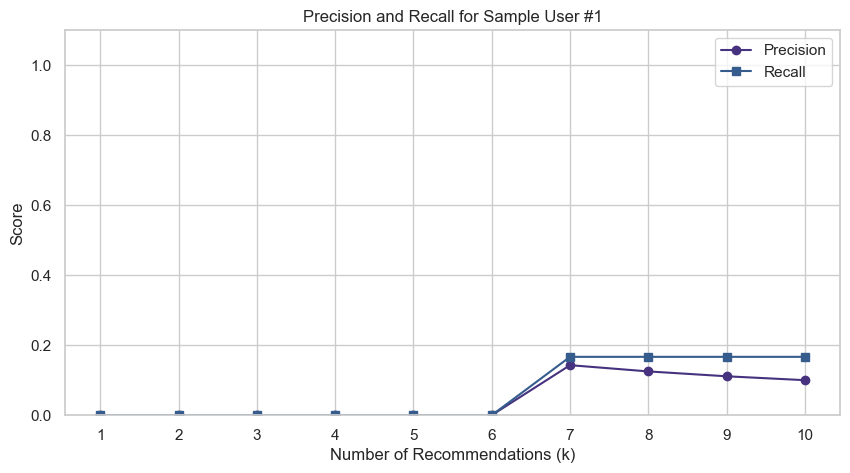


Analysis for Sample User #2:
  Input Items: {'Cold-Pressed Organic Grapefruit', 'Limes', 'Organic Roma Tomato', 'Crenshaw Melon'}
  Ground Truth: {'Cherry Garcia Ice Cream', 'Cookie Dough Ice Cream', 'Sourdough Bread', 'Large Lemon'}
  -> Input item 'Organic Roma Tomato' triggered 3 rule(s).
  -> Input item 'Limes' triggered 16 rule(s).
    For k=1:
      - Recommended (1 items): {'Large Lemon'}
      - SUCCESS! Matched items: {'Large Lemon'}
    For k=2:
      - Recommended (2 items): {'Large Lemon', 'Banana'}
      - SUCCESS! Matched items: {'Large Lemon'}
    For k=3:
      - Recommended (3 items): {'Large Lemon', 'Banana', 'Bag of Organic Bananas'}
      - SUCCESS! Matched items: {'Large Lemon'}
    For k=4:
      - Recommended (4 items): {'Large Lemon', 'Banana', 'Bag of Organic Bananas', 'Organic Baby Spinach'}
      - SUCCESS! Matched items: {'Large Lemon'}
    For k=5:
      - Recommended (5 items): {'Banana', 'Organic Baby Spinach', 'Bag of Organic Bananas', 'Organic Avocado'

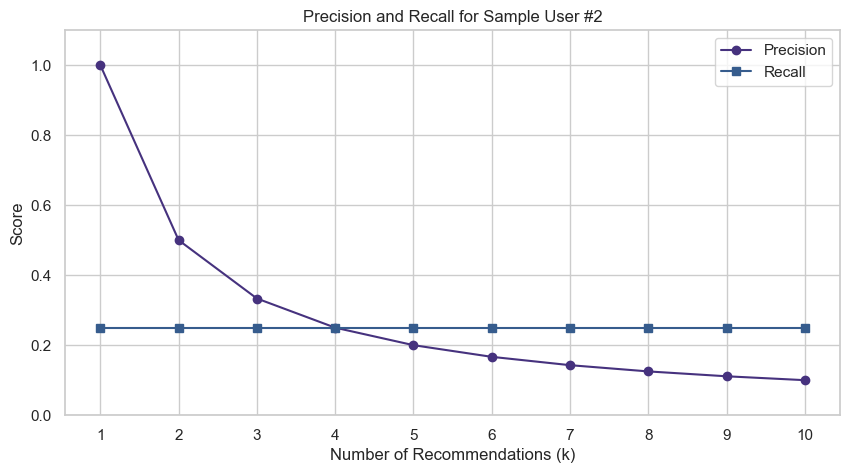


Analysis for Sample User #3:
  Input Items: {'Marketplace Vermont White Cheddar Mac & Cheese', '2% Chocolate Milk', 'Special K Barbecue Cracker Chips', 'Eggo Blueberry Waffles', 'Eggo Chocolate Chip Waffles'}
  Ground Truth: {'Meatloaf and Mashed Potatoes', 'Peanut Butter Crunch Cereal', 'French Vanilla Sugar Free Liquid Coffee Creamer', 'Energy On The Go Wild Strawberry Drink Mix', 'Special K Sour Cream & Onion Cracker Chips'}
  -> No rules were triggered by any item in this user's cart.
    For k=1:
      - Recommended (0 items): None
    For k=2:
      - Recommended (0 items): None
    For k=3:
      - Recommended (0 items): None
    For k=4:
      - Recommended (0 items): None
    For k=5:
      - Recommended (0 items): None
    For k=6:
      - Recommended (0 items): None
    For k=7:
      - Recommended (0 items): None
    For k=8:
      - Recommended (0 items): None
    For k=9:
      - Recommended (0 items): None
    For k=10:
      - Recommended (0 items): None


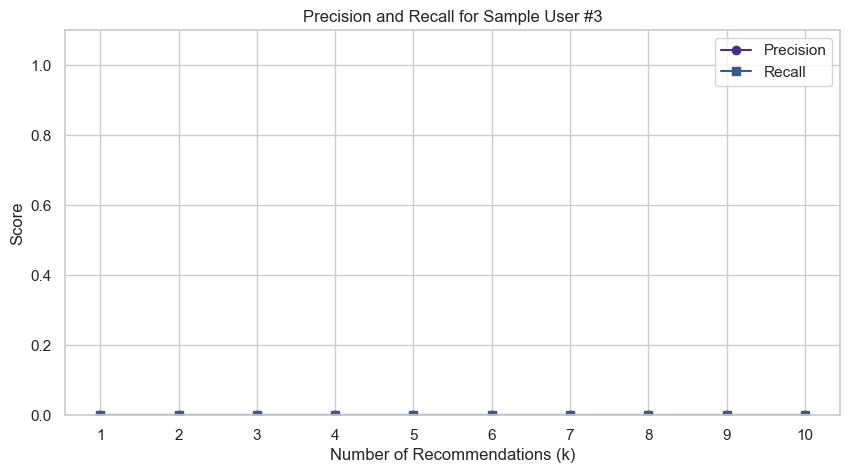


Analysis for Sample User #4:
  Input Items: {'Organic Cilantro', 'Red Onions', 'Sparkling Lemon Water', 'Organic Whole Grain Wheat English Muffins'}
  Ground Truth: {'Organic Light Brown Sugar', 'Tortilla Chips, Clasico, Jalapeno Lime', 'Organic 100% Whole Wheat Loaf', 'Vegan Flaxbread Breakfast Sandwiches 2 Count'}
  -> Input item 'Sparkling Lemon Water' triggered 2 rule(s).
  -> Input item 'Organic Cilantro' triggered 20 rule(s).
    For k=1:
      - Recommended (1 items): {'Limes'}
    For k=2:
      - Recommended (2 items): {'Limes', 'Lime Sparkling Water'}
    For k=3:
      - Recommended (3 items): {'Limes', 'Lime Sparkling Water', 'Sparkling Water Grapefruit'}
    For k=4:
      - Recommended (4 items): {'Limes', 'Lime Sparkling Water', 'Sparkling Water Grapefruit', 'Bag of Organic Bananas'}
    For k=5:
      - Recommended (5 items): {'Organic Baby Spinach', 'Bag of Organic Bananas', 'Limes', 'Lime Sparkling Water', 'Sparkling Water Grapefruit'}
    For k=6:
      - Recommende

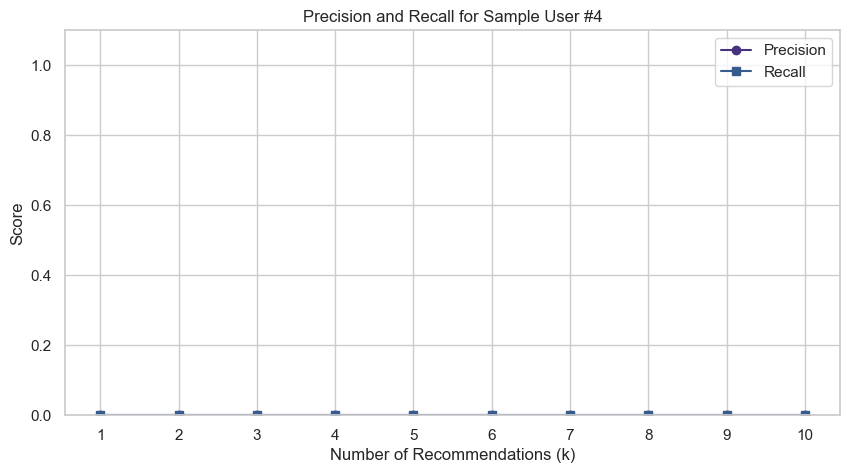


Analysis for Sample User #5:
  Input Items: {"Grab 'N Go® Cups & Lids 12 Ounce", 'Vanilla Frozen Dairy Dessert Sandwiches', 'Chunky Peanut Butter Chocolate High Protein Bars', 'Foam Bowls', 'smartwater® Electrolyte Enhanced Water', 'Arnold Palmer Lite Half & Half Iced Tea Lemonade', 'Original Glass Cleaner With Ammonia-D', 'Fridge Pack Cola', 'Barbeque Potato', '2-Ply White Tissues', 'Jolly Rancher'}
  Ground Truth: {'Whole Grain Oat Cereal', '1% Low Fat Milk', 'Mega Pack Everyday Plates', 'Ultra  April Fresh Scent Liquid Fabric Softener', 'Complete ActionPacs Fresh Scent Dishwasher Detergent', 'Clean Up Cleaner with Bleach Fresh Scent', 'Sparkling Water, Bottles', 'Paper Towels Choose-A-Sheet, Mega Rolls, One-Ply', 'Original Scent HE Laundry Detergent', 'Diet 12 Oz Ginger Ale', 'Original Cereal', 'Variety Diet Tea'}
  -> No rules were triggered by any item in this user's cart.
    For k=1:
      - Recommended (0 items): None
    For k=2:
      - Recommended (0 items): None
    For k=

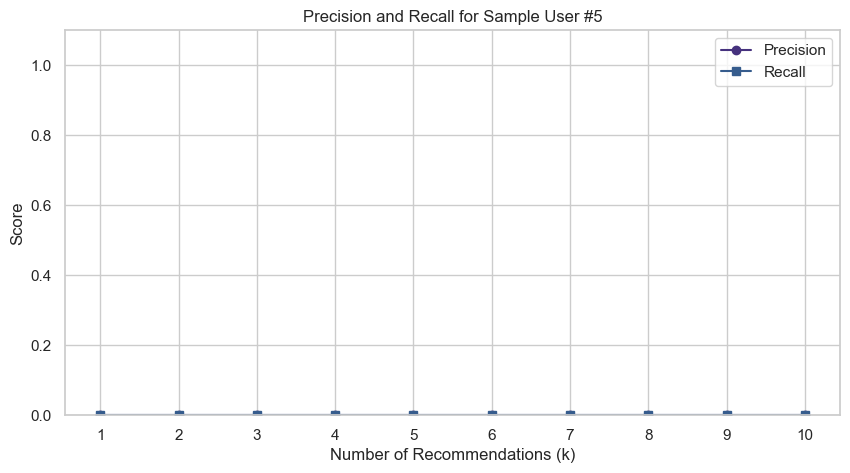

In [ ]:
# Part 4: Sample Analysis for a Few Users
print("\n--- Part 4: Analysis of sample users from the test set ---")


# Randomly select 5 users from the test set for detailed analysis
sample_indices = np.random.choice(len(test_inputs), 5, replace=False)

for i, user_index in enumerate(sample_indices):
    user_input = test_inputs[user_index]
    user_ground_truth = test_ground_truths[user_index]
    
    user_precisions, user_recalls = [], []
    for k in recommendation_counts:
        recs = get_recommendations(user_input, k)
        prec, rec = calculate_precision_recall(recs, user_ground_truth)
        user_precisions.append(prec)
        user_recalls.append(rec)

    # Convert IDs to names for printing
    input_names = {product_id_to_name.get(str(pid), f"ID:{pid}") for pid in user_input}
    gt_names = {product_id_to_name.get(str(pid), f"ID:{pid}") for pid in user_ground_truth}
    
    print(f"\nAnalysis for Sample User #{i+1}:")
    print(f"  Input Items: {input_names}")
    print(f"  Ground Truth: {gt_names}")

     # Check which input items trigger a rule
    triggered_a_rule = False
    for item in user_input:
        if item in rules_dict:
            print(f"  -> Input item '{product_id_to_name.get(str(item))}' triggered {len(rules_dict[item])} rule(s).")
            triggered_a_rule = True
    
    if not triggered_a_rule:
        print("  -> No rules were triggered by any item in this user's cart.")

    user_precisions, user_recalls = [], []
    for k in recommendation_counts:
        recs = get_recommendations(user_input, k)
        
        # Print recommendations
        rec_names = {product_id_to_name.get(str(pid), f"ID:{pid}") for pid in recs}
        print(f"    For k={k}:")
        print(f"      - Recommended ({len(recs)} items): {rec_names if rec_names else 'None'}")
        
        prec, rec = calculate_precision_recall(recs, user_ground_truth)
        user_precisions.append(prec)
        user_recalls.append(rec)

        # Print intersection
        intersection = recs.intersection(user_ground_truth)
        if intersection:
            intersection_names = {product_id_to_name.get(str(pid)) for pid in intersection}
            print(f"      - SUCCESS! Matched items: {intersection_names}")

    print("=============================================")
    
    # Plot results for this specific user
    plt.figure(figsize=(10, 5))
    plt.plot(recommendation_counts, user_precisions, marker='o', label='Precision')
    plt.plot(recommendation_counts, user_recalls, marker='s', label='Recall')
    plt.title(f'Precision and Recall for Sample User #{i+1}')
    plt.xlabel('Number of Recommendations (k)')
    plt.ylabel('Score')
    plt.xticks(recommendation_counts)
    plt.ylim(0, 1.1)
    plt.legend()
    plt.grid(True)
    plt.show()